# 🚢 Titanic Survival Prediction (Logistic Regression)
**Objective:** Predict whether a passenger survived or not based on their demographics and ticket information. This is a classic **Binary Classification** problem. We will build a robust `scikit-learn` pipeline to handle missing values, encode categorical data, and evaluate the model using a Confusion Matrix.

In [1]:
# 1. Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(" Libraries Imported Successfully!")

 Libraries Imported Successfully!


---
### 📂 Step 1: Load Data & Smart Cleaning
Instead of dropping all missing values (which deletes ~80% of the dataset due to the `deck` column), we will drop columns with excessive missing data and redundant features.

In [2]:
# Load Dataset
df = pd.read_csv('titanic_data.csv')

# Smart Cleaning: Drop redundant or highly missing columns
# - 'deck': Too many missing values
# - 'alive': Exact duplicate of 'survived' (Target Leakage)
# - 'class': Duplicate of 'pclass'
# - 'embark_town': Duplicate of 'embarked'
columns_to_drop = ['deck', 'alive', 'class', 'embark_town', 'who']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Drop duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Cleaned Dataset Shape: {df.shape}")
display(df.head())

Cleaned Dataset Shape: (778, 10)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,True,False
1,1,1,female,38.0,1,0,71.2833,C,False,False
2,1,3,female,26.0,0,0,7.9250,S,False,True
3,1,1,female,35.0,1,0,53.1000,S,False,False
4,0,3,male,35.0,0,0,8.0500,S,True,True


---
### 📊 Step 2: Exploratory Data Analysis (EDA)
Let's explore the survival rate, especially across different genders and passenger classes.

C:\Users\ahmed\AppData\Local\Temp\ipykernel_14288\645837877.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='survived', palette='Set1')


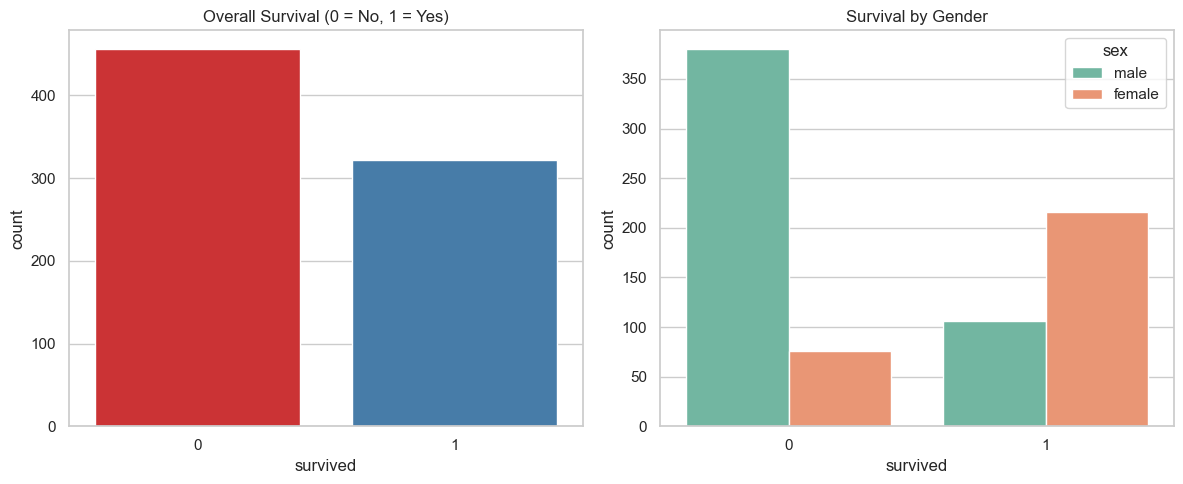

 Observation: Females had a noticeably higher survival rate compared to males.


In [3]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot 1: Overall Survival Count
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='survived', palette='Set1')
plt.title('Overall Survival (0 = No, 1 = Yes)')

# Plot 2: Survival by Gender
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='survived', hue='sex', palette='Set2')
plt.title('Survival by Gender')

plt.tight_layout()
plt.show()

print(" Observation: Females had a noticeably higher survival rate compared to males.")

---
### ✂️ Step 3: Feature Separation & Train-Test Split

In [4]:
# Separate Features (X) and Target (y)
X = df.drop('survived', axis=1)
y = df['survived']

# Split Data (80% Train, 20% Test) - 'stratify=y' ensures the same ratio of survivors in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify column types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns

---
### 🏗️ Step 4: Build the Classification Pipeline

In [5]:
# 1. Numerical Pipeline (Impute missing age with median, then scale)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Categorical Pipeline (Impute missing embarked with mode, then One-Hot Encode)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Combine Preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# 4. Full Pipeline with Logistic Regression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

print(" Classification Pipeline Built Successfully")

 Classification Pipeline Built Successfully


---
### 🚀 Step 5: Train, Evaluate, and Visualize Results
For classification, accuracy is not enough. We must look at the **Confusion Matrix** to see True Positives, False Positives, etc.

🏆 Model Accuracy: 83.33%

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        91
           1       0.82      0.77      0.79        65

    accuracy                           0.83       156
   macro avg       0.83      0.82      0.83       156
weighted avg       0.83      0.83      0.83       156



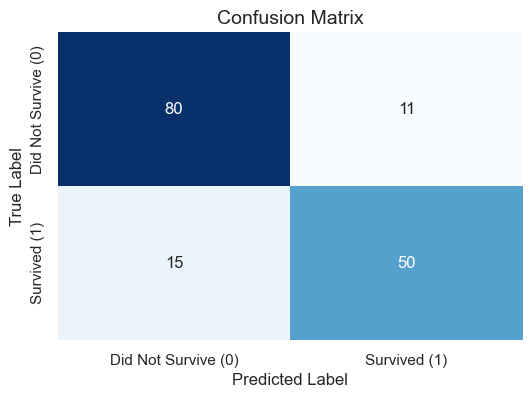

In [6]:
# Train Model
model_pipeline.fit(X_train, y_train)

# Predict
y_pred = model_pipeline.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"🏆 Model Accuracy: {acc * 100:.2f}%\n")

print("📄 Classification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# 📈 Visualizing the Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Did Not Survive (0)', 'Survived (1)'],
            yticklabels=['Did Not Survive (0)', 'Survived (1)'])

plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()